In [2]:
from pathlib import Path
import matplotlib.ticker as mticker
import pandas
from matplotlib import pyplot as plt

In [6]:
scopus_result_path = Path("scopus_results/included_results.csv")
df = pandas.read_csv(scopus_result_path)
df.to_clipboard()

,id,project_id,probability,pmid,refman,title,abstract,authors,journal,volume,...,filename,resolution_labels,resolution_labels_alternate,labels,labels_alternate,tags,general,population,intervention_comparator,outcome
0,4290040,3614,0,NaN,NaN,Quantum kernel estimation-based quantum suppor...,Quantum machine learning endeavors to exploit ...,"Zhou, Xiaojian (55743236400); Yu, Jieyao (5798...",Quantum Information Processing,23,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
1,4290037,3614,0,NaN,NaN,QAISim: a toolkit for modeling and simulation ...,Quantum computing offers new ways to explore t...,"Singh, Irwindeep (60286751400); Gill, Sukhpal ...",Cluster Computing,29,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
2,4290036,3614,0,NaN,NaN,Quantum-Based QoE Optimization in Advanced Cel...,This work explores the integration of Quantum ...,"Chaouech, Fatma (60057005200); Villegas, Javie...",IEEE Open Journal of the Communications Society,6,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
3,4290035,3614,0,NaN,NaN,Parallel hybrid quantum-classical machine lear...,Supervised time-series classification garners ...,"Baker, Jack S. (57462192800); Park, Gilchan (5...",Quantum Machine Intelligence,6,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
4,4290032,3614,0,NaN,NaN,Quantum-Enhanced Dual-Backbone Architecture fo...,Background: Quantum machine learning (QML) hol...,"Marzoug, Nabil (58817844100); Halab, Khidhr (5...",BioMedInformatics,5,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,4289594,3614,0,NaN,NaN,Quantum generative learning for high-resolutio...,Integration of quantum computing in generative...,"Khatun, Amena (57212796083); Yeter Aydeniz, Kü...",Machine Learning: Science and Technology,6,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
196,4289593,3614,0,NaN,NaN,Development of variational quantum deep neural...,Parametrized quantum circuits are widely used ...,"Wang, Yunqian (57201779541); Wang, Yufeng (577...",Neurocomputing,501,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
197,4289592,3614,0,NaN,NaN,New perspectives on structural health monitori...,This study presents a novel approach using uns...,"Higino Meneguitte Alves, Victor (59644697100);...",Mechanical Systems and Signal Processing,229,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN
198,4289591,3614,0,NaN,NaN,Quantum enhanced stratification of breast canc...,Quantum machine learning (QML) is considered o...,"Repetto, Valeria (57224996797); Ceroni, Elia G...",Quantum Machine Intelligence,7,...,scopus_export_Mar 13-2026_bd893968-dc41-4186-9...,NaN,NaN,1,yes,NaN,NaN,NaN,NaN,NaN


In [19]:
top_df = df[["Title", "Cited by"]]
top_df = top_df.sort_values(by=["Cited by"], ascending=False).head(10)

manual_labels = {
	"temp": "temp"
}

top_df["Short Title"] = top_df["Title"].map(lambda x: manual_labels.get(x, x))
top_df

,Title,Cited by,Short Title
153,Quantum Machine Learning for 6G Communication ...,579,Quantum Machine Learning for 6G: [...]
441,Quantum convolutional neural network for class...,298,Quantum convolutional neural network for class...
432,Layerwise learning for quantum neural networks,240,Layerwise learning for quantum neural networks
75,Machine Learning: Quantum vs Classical,184,Machine Learning: Quantum vs Classical
255,Hybrid quantum–classical generative adversaria...,156,Hybrid quantum–classical generative adversaria...
12,Quantum generative adversarial network for gen...,136,Quantum generative adversarial network for gen...
323,Comparative performance analysis of quantum ma...,133,Comparative performance analysis of quantum ma...
367,Opportunities in Quantum Reservoir Computing a...,119,Opportunities in Quantum Reservoir Computing a...
409,Quantum machine learning for image classification,114,Quantum machine learning for image classification
312,Variational quantum reinforcement learning via...,98,Variational quantum reinforcement learning via...


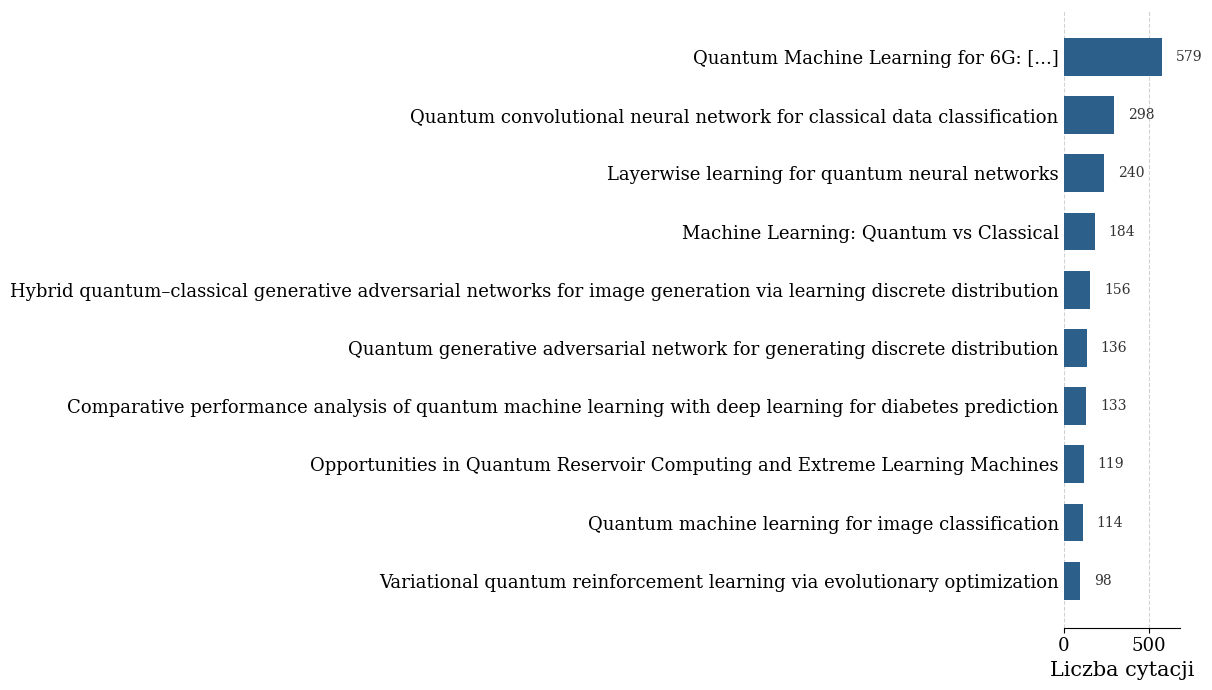

In [20]:
plt.rcParams.update({
	"font.family": "serif",
	"axes.titlesize": 18,
	"axes.labelsize": 15,
	"xtick.labelsize": 13,
	"ytick.labelsize": 13,
})

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
	top_df["Short Title"],
	top_df["Cited by"],
	color="#2c5f8a",
	edgecolor="none",
	height=0.65,
)

for bar in bars:
	width = bar.get_width()
	ax.text(
		width + 80,
		bar.get_y() + bar.get_height() / 2,
		f"{int(width):,}".replace(",", "\u202f"),
		va="center",
		ha="left",
		fontsize=10,
		color="#333333",
	)

ax.invert_yaxis()
ax.set_xlabel("Liczba cytacji")
ax.set_xlim(0, top_df["Cited by"].max() * 1.18)

ax.xaxis.set_major_formatter(
	mticker.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "\u202f"))
)

ax.grid(axis="x", linestyle="--", alpha=0.35, color="grey")
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
	ax.spines[spine].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig(r"results\top10_cytowania.svg", format='svg', bbox_inches="tight")
plt.show()